# 07. Interpolative QTT Construction

## Learning goals

- understand how multiscale polynomial interpolation gives rise to low-rank QTTs
- build a QTT from only $2(N+1)$ function evaluations using `IQTT.interpolatesinglescale`
- apply the multiresolution (adaptive) construction for functions with sharp features using `IQTT.interpolateadaptive`
- use sparse local Lagrange interpolation to reduce construction cost with `IQTT.interpolatesinglescale_sparse`
- compare approximation errors and bond dimensions across all three methods

## Before you run this notebook

From a terminal in the repository root, run:

```bash
julia --project=. -e 'using Pkg; Pkg.instantiate(); Pkg.resolve(); Pkg.build("Tensor4all"); Pkg.precompile()'
```

Then open the notebook in VS Code or Jupyter and select the Julia 1.12 kernel that matches the version you used for setup. The current `Manifest.toml` was resolved with Julia 1.12.5, so a Julia 1.11 kernel can fail during package loading.

In [27]:
using Tensor4all
using CairoMakie
using LaTeXStrings
import Tensor4all.QuanticsGrids as QG
import Tensor4all.QuanticsTCI as QTCI
import Tensor4all.TensorNetworks as TN
import Tensor4all.SimpleTT as STT
import Tensor4all.InterpolativeQTT as IQTT

## Background

The three constructions covered in this notebook are:

| Method | Function evaluations | Construction cost | When to use |
|--------|---------------------|-------------------|-------------|
| Single-scale | $2(N+1)$ | $O(N^2 r)$ | smooth functions |
| Adaptive (multiresolution) | $\propto N \cdot K$ | $O(N^2 r K)$ | functions with localised sharp features |
| Sparse | $2(N+1)$ | $O(Nr^2)$ | large $N$, well-separated scales |

**Notation note:** In this notebook we follow the `InterpolativeQTT.jl` convention:
- `R` = QTT depth (number of binary levels; grid has $2^R$ points) — called $K$ in the Lindsey paper
- `K` or `N` = interpolation order ($N+1$ Chebyshev nodes used) — called $N$ in the Lindsey paper

## 1. Single-scale interpolation

`IQTT.interpolatesinglescale(f, a, b, R, K)` assembles this QTT:
- `f` — target function
- `[a, b]` — physical interval (the grid is mapped from $[0,1]$ to $[a,b]$ automatically)
- `R` — QTT depth (grid has $2^R$ points)
- `K` — interpolation order; uses $K+1$ Chebyshev–Lobatto nodes and requires only $2(K+1)$ evaluations of `f`

In [50]:
f(x) = cos(x^2) + sin(π * x)
a, b = -2.0, sqrt(2)
R = 8   # QTT depth: grid has 2^R = 256 points
K = 10  # interpolation order: uses K+1 = 11 Chebyshev nodes → only 2*(K+1) = 22 function evaluations

tt = IQTT.interpolatesinglescale(f, a, b, R, K)

grid        = QG.DiscretizedGrid{1}(R, a, b)
plotquantics = QG.grididx_to_quantics.(Ref(grid), 1:(2^R))
plotx        = QG.grididx_to_origcoord.(Ref(grid), 1:(2^R))
origdata     = f.(plotx)
ttdata       = tt.(plotquantics)

max_err = maximum(abs.(ttdata .- origdata))
println("QTT depth R=$R,  interpolation order K=$K")
println("Function evaluations used: $(2*(K+1))  (vs $(2^R) for brute force)")
println("Maximum absolute error on grid: $max_err")

QTT depth R=8,  interpolation order K=10
Function evaluations used: 22  (vs 256 for brute force)
Maximum absolute error on grid: 9.657968959242424e-6


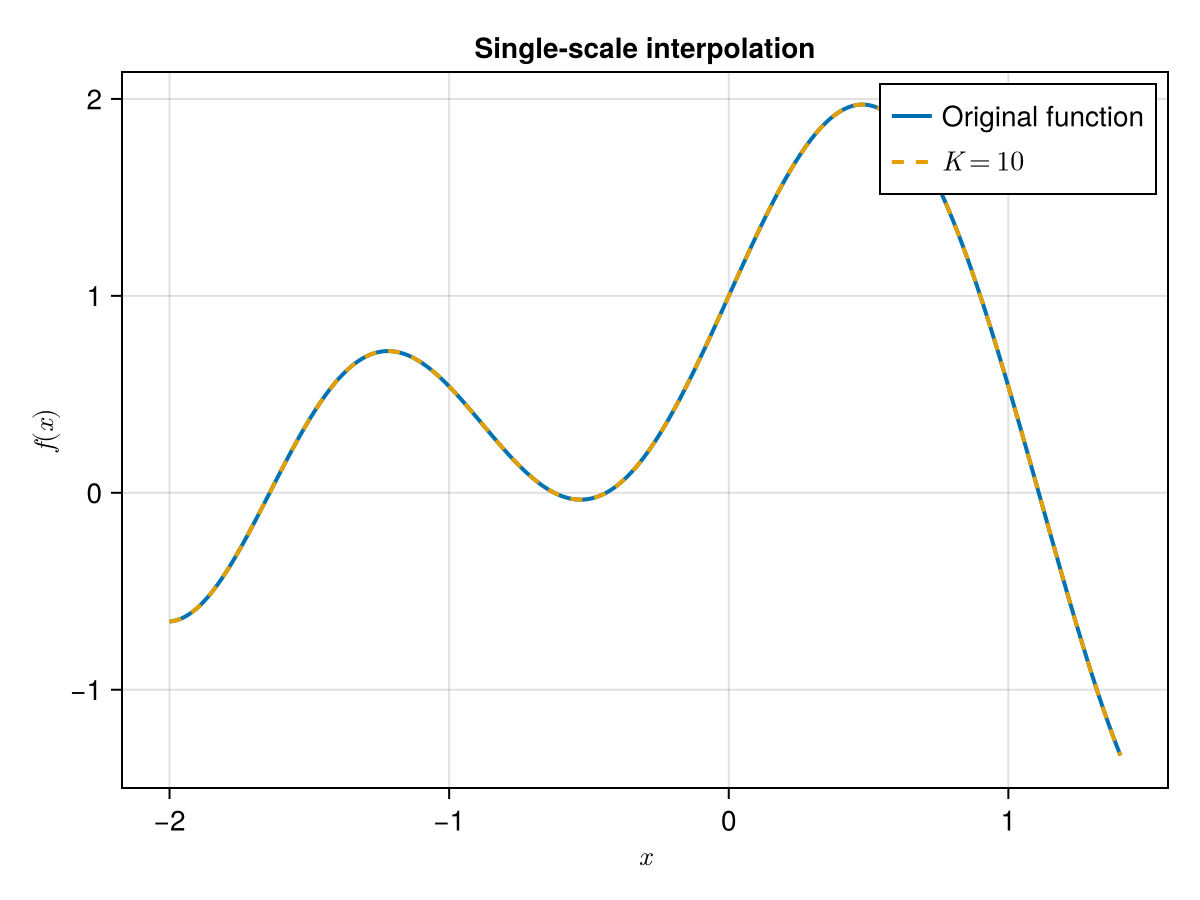

In [51]:
let
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)", title = "Single-scale interpolation")
    lines!(ax, plotx, f.(plotx), label = "Original function", linewidth = 2.0, linestyle = :solid)
    lines!(ax, plotx, ttdata, label = L"K=%$K", linewidth = 2.0, linestyle = :dash)
    axislegend(ax, pos = :best)
    fig
end

In [52]:
# Sweep over interpolation order K to see how accuracy grows with the number of Chebyshev nodes.
# Each value of K only uses 2*(K+1) function evaluations.
K_values = [4, 6, 8, 10, 12, 15, 20]
errors_K  = Float64[]

for Ki in K_values
    tti = IQTT.interpolatesinglescale(f, a, b, R, Ki)
    err = maximum(abs.(tti.(plotquantics) .- origdata))
    push!(errors_K, err)
    println("K=$Ki  ($(2*(Ki+1)) evals)  →  max err = $err")
end

K=4  (10 evals)  →  max err = 0.12005524174184706
K=6  (14 evals)  →  max err = 0.011703772903765786
K=8  (18 evals)  →  max err = 0.00048275702620192984
K=10  (22 evals)  →  max err = 9.657968959242424e-6
K=12  (26 evals)  →  max err = 9.307955098902809e-7
K=15  (32 evals)  →  max err = 4.9536720836407255e-9
K=20  (42 evals)  →  max err = 4.426015109970649e-12


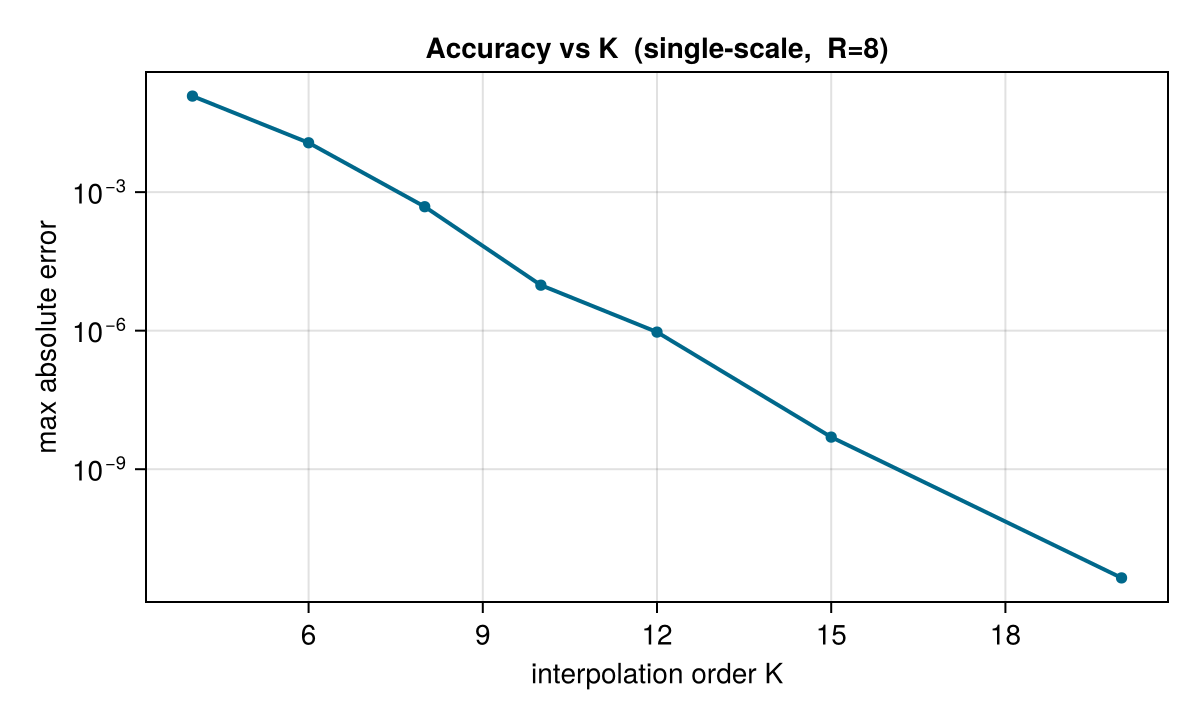

In [53]:
let
    fig = Figure(size = (600, 360))
    ax = Axis(fig[1, 1], xlabel = "interpolation order K", ylabel = "max absolute error",
              title = "Accuracy vs K  (single-scale,  R=$R)",
              yscale = log10)
    scatterlines!(ax, K_values, errors_K, linewidth = 2, color = :deepskyblue4, markersize = 8)
    fig
end

This exponential convergence is the payoff of Chebyshev interpolation: for a function analytic on the interval, the interpolation error decays as $\rho^{-N}$ where $\rho > 1$ is the size of the largest Bernstein ellipse to which the function extends analytically (Proposition 5 of Lindsey 2024).

## 2. Adaptive (multiresolution) interpolation


`IQTT.interpolateadaptive(f, a, b, R, K)` applies a adaptive strategy automatically. 

In [54]:
α = 0.01  # small α → very sharp Gaussian centred at x=0
f(x) = exp(-0.5 * (x / α)^2)
a, b = 0.0, 1.0
R = 8   # QTT depth
K = 18  # interpolation order — N=18 gives machine precision for this Gaussian (cf. Fig. 8.5 of Lindsey 2024)

tt_single   = IQTT.interpolatesinglescale(f, a, b, R, K)
tt_adaptive = IQTT.interpolateadaptive(f, a, b, R, K)

grid         = QG.DiscretizedGrid{1}(R, a, b)
plotquantics = QG.grididx_to_quantics.(Ref(grid), 1:(2^R))
plotx        = QG.grididx_to_origcoord.(Ref(grid), 1:(2^R))
origdata     = f.(plotx)

err_single   = maximum(abs.(tt_single.(plotquantics)   .- origdata))
err_adaptive = maximum(abs.(tt_adaptive.(plotquantics) .- origdata))

println("α = $α,  R=$R,  K=$K")
println("Single-scale max error:   $err_single")
println("Adaptive max error:       $err_adaptive")

α = 0.01,  R=8,  K=18
Single-scale max error:   0.021968734914486476
Adaptive max error:       6.1102234383270115e-12


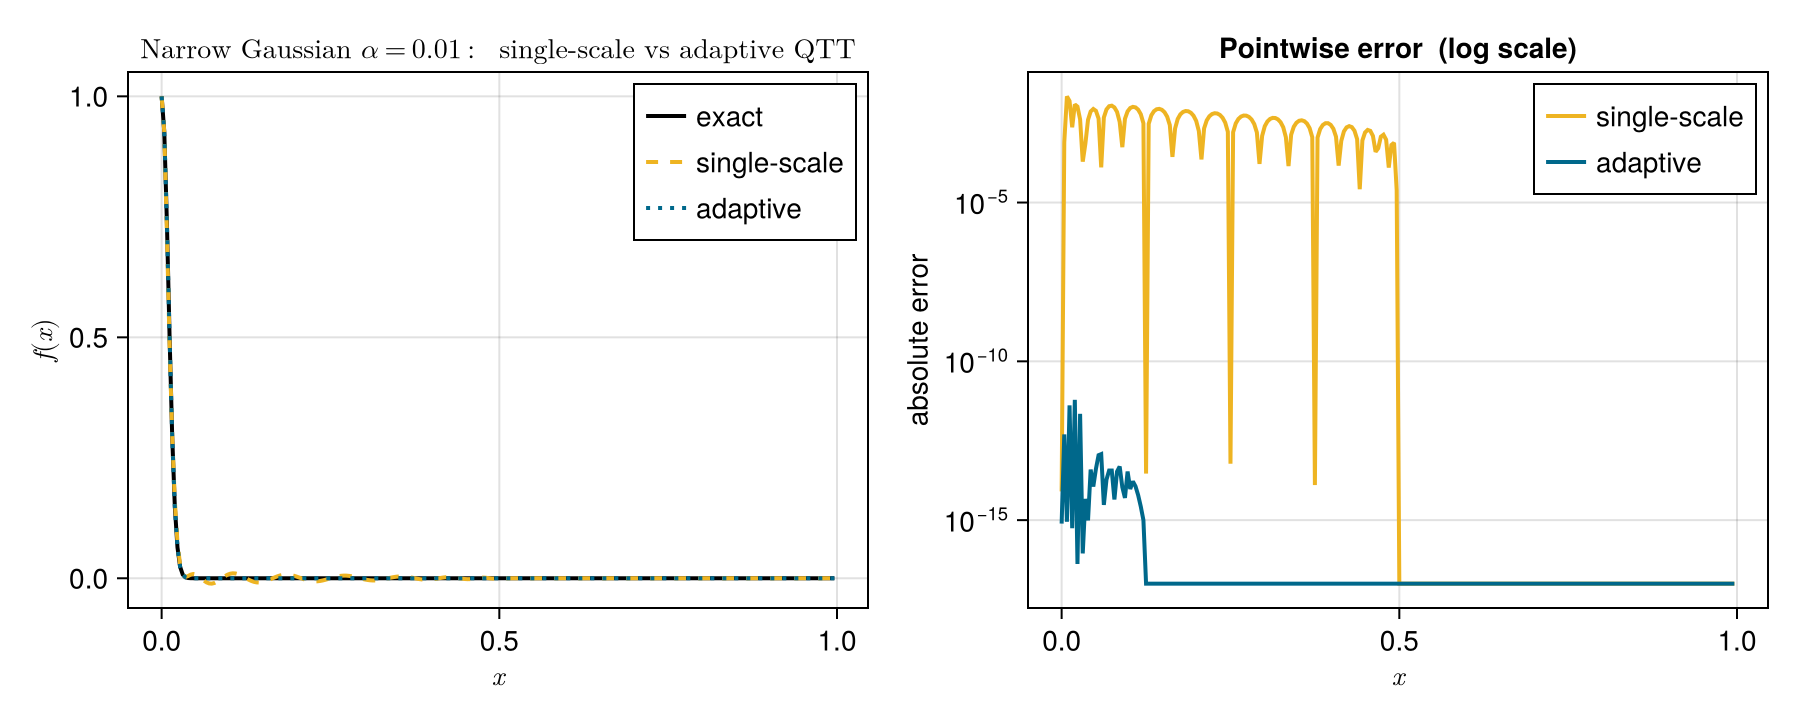

In [55]:
let
    fig = Figure(size = (900, 360))

    ax1 = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",
               title = L"Narrow Gaussian $\alpha=%$α$:  single-scale vs adaptive QTT")
    lines!(ax1, plotx, origdata,                        label = "exact",        linewidth = 2, color = :black)
    lines!(ax1, plotx, tt_single.(plotquantics),        label = "single-scale", linewidth = 2, color = :goldenrod2,   linestyle = :dash)
    lines!(ax1, plotx, tt_adaptive.(plotquantics),      label = "adaptive",     linewidth = 2, color = :deepskyblue4, linestyle = :dot)
    axislegend(ax1, position = :rt)

    ax2 = Axis(fig[1, 2], xlabel = L"x", ylabel = "absolute error",
               title = "Pointwise error  (log scale)", yscale = log10)
    lines!(ax2, plotx, max.(abs.(tt_single.(plotquantics)   .- origdata), 1e-17), label = "single-scale", linewidth = 2, color = :goldenrod2)
    lines!(ax2, plotx, max.(abs.(tt_adaptive.(plotquantics) .- origdata), 1e-17), label = "adaptive",     linewidth = 2, color = :deepskyblue4)
    axislegend(ax2, position = :rt)

    fig
end

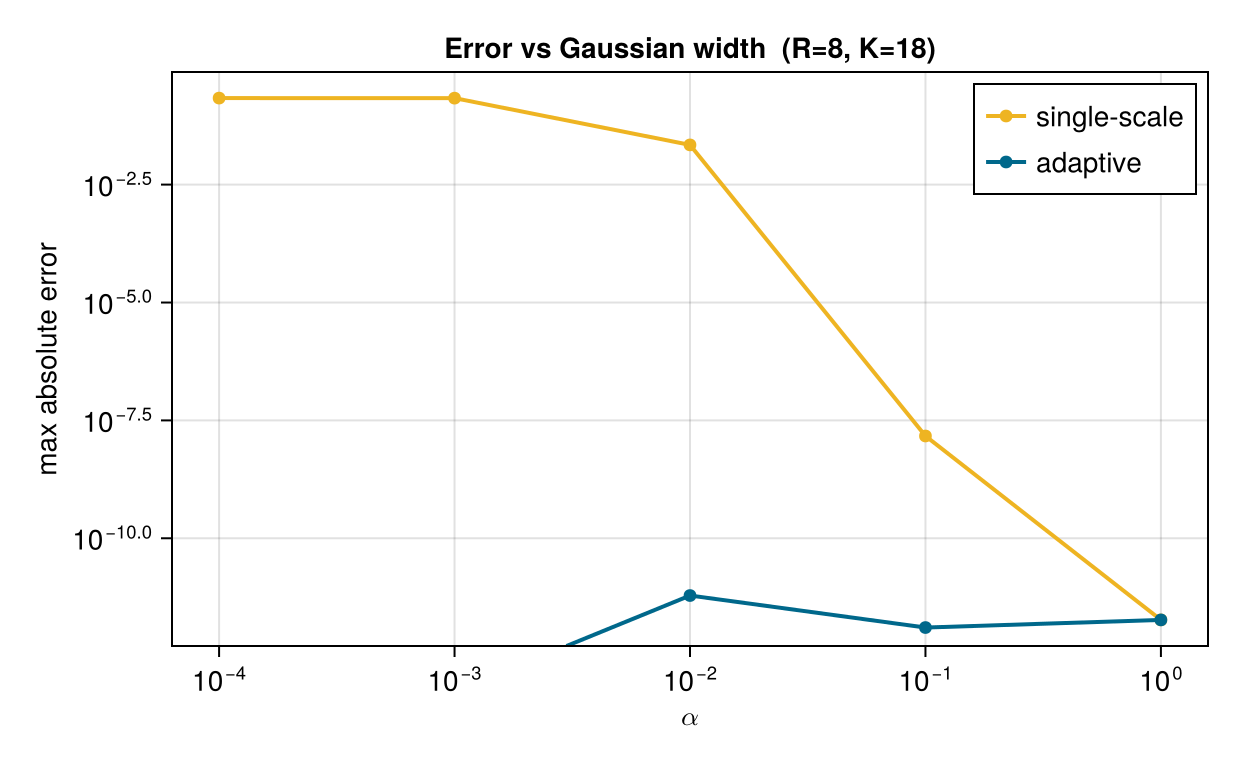

In [56]:
# Sweep over α to confirm that the adaptive construction maintains bounded error
# even as the Gaussian becomes arbitrarily narrow (Figure 8.5 of Lindsey 2024).
α_values         = [1.0, 0.1, 0.01, 0.001, 0.0001]
errs_single_α    = Float64[]
errs_adaptive_α  = Float64[]

for αi in α_values
    fi(x)  = exp(-0.5 * (x / αi)^2)
    grid_i = QG.DiscretizedGrid{1}(R, 0.0, 1.0)
    qi     = QG.grididx_to_quantics.(Ref(grid_i), 1:(2^R))
    xi     = QG.grididx_to_origcoord.(Ref(grid_i), 1:(2^R))
    ori    = fi.(xi)
    push!(errs_single_α,   maximum(abs.(IQTT.interpolatesinglescale(fi, 0.0, 1.0, R, K).(qi)  .- ori)))
    push!(errs_adaptive_α, maximum(abs.(IQTT.interpolateadaptive(fi, 0.0, 1.0, R, K).(qi)     .- ori)))
end

let
    fig = Figure(size = (620, 380))
    ax = Axis(fig[1, 1], xlabel = L"\alpha", ylabel = "max absolute error",
              title = "Error vs Gaussian width  (R=$R, K=$K)",
              xscale = log10, yscale = log10)
    scatterlines!(ax, α_values, errs_single_α,   label = "single-scale", linewidth = 2, color = :goldenrod2)
    scatterlines!(ax, α_values, errs_adaptive_α, label = "adaptive",     linewidth = 2, color = :deepskyblue4)
    axislegend(ax, position = :rt)
    fig
end

The adaptive construction keeps the error bounded across all values of $\alpha$, confirming the theory. The single-scale construction degrades as $\alpha$ shrinks because the global interpolation order $K$ is no longer sufficient to resolve the increasingly sharp peak from the coarse top-level Chebyshev grid. The adaptive construction sidesteps this by deferring interpolation inside the dangerous interval $[0, 2^{-k}]$ at each scale, so it never attempts a single-level interpolation across the peak.

## 3. Sparse interpolation

The **sparse construction** (Section 4.3 of Lindsey 2024, following Boyd 1992) replaces the dense Chebyshev cardinal functions $P^\alpha$ with a **local Lagrange interpolation** in the angular coordinate $\theta = \arccos(2x-1)$. For each output point, only the nearest $2M+1$ Chebyshev nodes (in $\theta$-space) are used, so each column of the interpolating core $\tilde{A}(\sigma)$ has $O(M)$ nonzero entries. The construction cost drops to $O(Nr^2)$.

The bandwidth $M$ controls the accuracy–speed trade-off:
- Small $M$ (e.g. 5–10): fast construction; converges as $N\to\infty$ for fixed $M$, but requires larger $N$ to compensate
- Large $M$ (close to $N$): approaches the dense construction; high accuracy at smaller $N$

The convergence in $N$ for fixed $M$ is exponential in $M$, so even modest $M$ can reach machine precision for large enough $N$.

This is particularly useful for peaked functions like the Lorentzian

$$f(x) = \frac{\alpha}{\sqrt{\alpha^2 + (x-\tfrac{1}{2})^2}}, \quad \alpha \ll 1,$$

where the required $N$ scales as $N\sim C/\sqrt{\alpha}$ to maintain fixed accuracy (Section 8.2 of Lindsey 2024).

`IQTT.interpolatesinglescale_sparse(f, a, b, R, N, M)` adds the bandwidth `M` to the dense signature.

Dense  N=100:  max err = 1.1546319456101628e-12
Sparse N=200 M=5:  max err = 1.144973005295924e-12
Sparse N=200 M=10:  max err = 1.3816725541460073e-12
Sparse N=200 M=15:  max err = 6.876388347620832e-12
Sparse N=200 M=20:  max err = 9.720391158651864e-12
Sparse N=200 M=30:  max err = 2.5548319682044962e-8


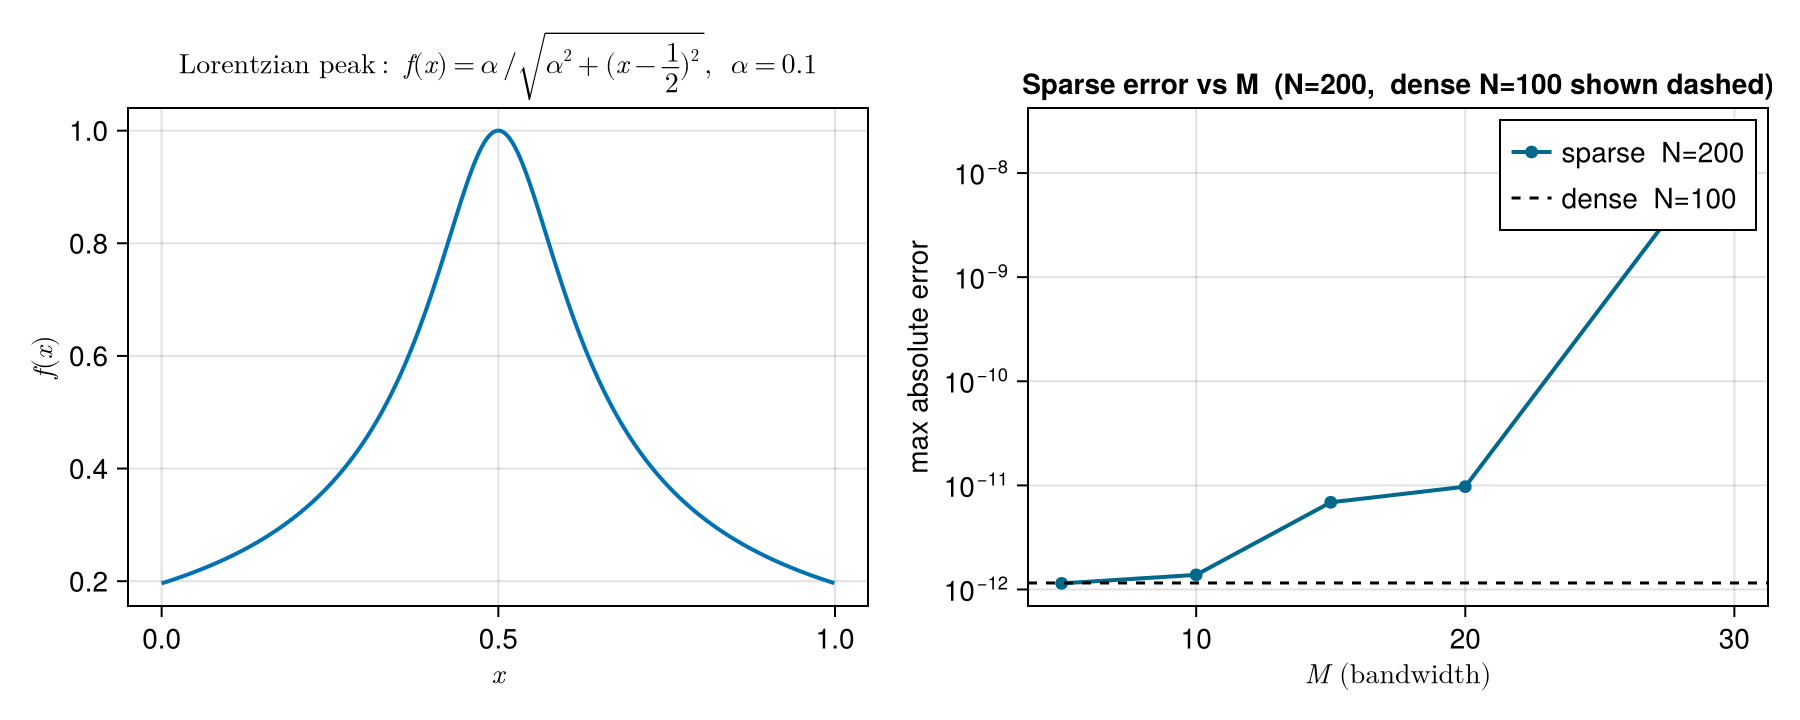

In [57]:
α = 0.1
f(x) = α / sqrt(α^2 + (x - 0.5)^2)
a, b = 0.0, 1.0
R = 10    # QTT depth: 2^10 = 1024 grid points
N_dense  = 100   # dense construction interpolation order
N_sparse = 200   # sparse construction interpolation order (larger N, sparse cores stay cheap)

grid         = QG.DiscretizedGrid{1}(R, a, b)
quanticsinds = QG.grididx_to_quantics.(Ref(grid), 1:(2^R))
plotx        = QG.grididx_to_origcoord.(Ref(grid), 1:(2^R))
origdata     = f.(plotx)

tt_dense  = IQTT.interpolatesinglescale(f, a, b, R, N_dense)
err_dense = maximum(abs.(tt_dense.(quanticsinds) .- origdata))
println("Dense  N=$N_dense:  max err = $err_dense")

M_values    = [5, 10, 15, 20, 30]
tt_sparse   = [IQTT.interpolatesinglescale_sparse(f, a, b, R, N_sparse, M) for M in M_values]
errs_sparse = [maximum(abs.(tt.(quanticsinds) .- origdata)) for tt in tt_sparse]

for (M, err) in zip(M_values, errs_sparse)
    println("Sparse N=$N_sparse M=$M:  max err = $err")
end

let
    fig = Figure(size = (900, 360))
    ax1 = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",
               title = L"Lorentzian peak: $f(x) = \alpha\,/\sqrt{\alpha^2+(x-\frac{1}{2})^2}$,  $\alpha=%$α$")
    lines!(ax1, plotx, origdata, linewidth = 2)

    ax2 = Axis(fig[1, 2], xlabel = L"M \text{ (bandwidth)}", ylabel = "max absolute error",
               title = "Sparse error vs M  (N=$N_sparse,  dense N=$N_dense shown dashed)",
               yscale = log10)
    scatterlines!(ax2, M_values, errs_sparse, label = "sparse  N=$N_sparse", linewidth = 2, color = :deepskyblue4)
    hlines!(ax2, [err_dense], color = :black, linestyle = :dash, label = "dense  N=$N_dense")
    axislegend(ax2, position = :rt)
    fig
end

## What to notice

- The interpolative construction builds a QTT using only $2(N+1)$ function evaluations, regardless of the QTT depth $R$. This is the key advantage over TCI, which requires $O(2^R)$ evaluations in the worst case. 
- `IQTT.interpolatesinglescale` uses a dense Chebyshev-Lobatto grid and a rank-revealing left-to-right SVD sweep. The resulting QTT has ranks that tend to decay towards deeper levels (finer scales) for smooth functions, as predicted by the theory (Propositions 2 and 5 of Lindsey 2024).
- The exponential convergence in $K$ (interpolation order) is the hallmark of Chebyshev interpolation for analytic or highly differentiable functions. Smooth functions typically hit machine precision at modest $K$ (10–20).
- `IQTT.interpolateadaptive` maintains bounded error for functions with sharp features by deferring Chebyshev interpolation inside "dangerous" dyadic subintervals. The error bound is independent of how sharp the feature is.
- `IQTT.interpolatesinglescale_sparse` allows large $N$ to be used efficiently. The bandwidth $M$ is a second tuning parameter: larger $M$ gives higher accuracy at the cost of denser core matrices.
- The interpolative QTT approach and TCI are **complementary**: TCI is more general (works for arbitrary tensor trains, not just QTTs) but can fail for highly oscillatory functions, while the interpolative approach is restricted to QTTs but is always stable and uses far fewer evaluations.

**Reference:** M. Lindsey, *Multiscale interpolative construction of quantized tensor trains*, arXiv:2311.12554 (2024).

## API recap

- `Tensor4all.InterpolativeQTT.interpolatesinglescale(f, a, b, R, K)` — dense single-scale QTT; uses $2(K+1)$ evaluations of `f`
- `Tensor4all.InterpolativeQTT.interpolateadaptive(f, a, b, R, K)` — multiresolution (adaptive) QTT; handles functions with sharp features near $x=a$
- `Tensor4all.InterpolativeQTT.interpolatesinglescale_sparse(f, a, b, R, N, M)` — sparse single-scale QTT with local-Lagrange bandwidth `M`; same evaluations as dense but $O(Nr^2)$ cost
- `Tensor4all.QuanticsGrids.DiscretizedGrid{1}` — 1D quantics grid with $2^R$ points on $[a,b]$
- `Tensor4all.QuanticsGrids.grididx_to_quantics` — integer grid index → binary quantics index tuple
- `Tensor4all.QuanticsGrids.grididx_to_origcoord` — integer grid index → physical coordinate